In [3]:
x = torch.tensor([25.0])
x = x.unsqueeze(0)
x = x.squeeze()
print(x.shape)

torch.Size([])


In [1]:
import torch 
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

### Build a Data Pipeline

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307, ), (0.3081, ))
])

train_data = torchvision.datasets.MNIST(root='data', train=True, 
                    download=True, transform=transform)
test_data = torchvision.datasets.MNIST(root='data', train=False, 
                    download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=1000, shuffle=False)

In [3]:
train_data.data.shape, train_data.targets.shape

(torch.Size([60000, 28, 28]), torch.Size([60000]))

In [4]:
train_data.data[0]

tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,
          18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   

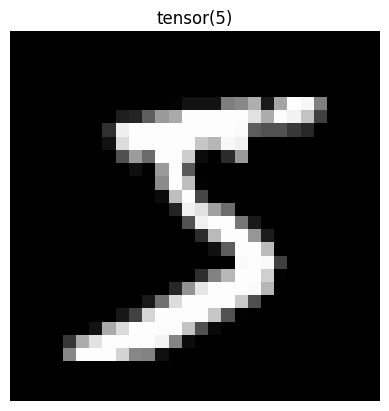

In [5]:
import matplotlib.pyplot as plt

plt.imshow(train_data.data[0], cmap='gray')
plt.title(train_data.targets[0])
plt.axis('off')
plt.show()

In [6]:
train_data.data[1]

tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,  51, 159, 253, 159,  50,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          48, 238, 252, 252, 252, 237,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   

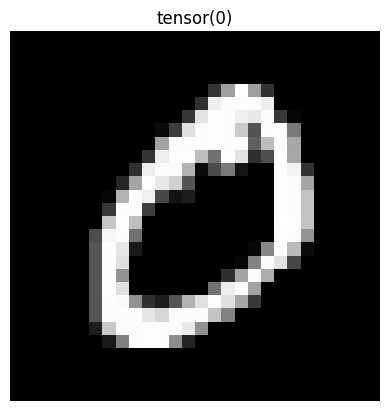

In [7]:
import matplotlib.pyplot as plt

plt.imshow(train_data.data[1], cmap='gray')
plt.title(train_data.targets[1])
plt.axis('off')
plt.show()

In [8]:
class MNISTClassificationModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
            )
    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits
    
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MNISTClassificationModel().to(device)
loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [9]:
print(model)

MNISTClassificationModel(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [10]:
## Training
def epoch_train(model, device, train_loader, optimizer, loss_function):
    model.train()
    running_loss, correct, total = 0.0, 0.0, 0.0
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = loss_function(output, target)
        loss.backward()
        optimizer.step()

        ## Track progress
        running_loss += loss.item()
        _, predicted = torch.max(output.data, 1)
        correct += (predicted == target).sum().item()
        total += target.size(0)

        ## Print every 100 batches
        if batch_idx % 100 == 0 and batch_idx > 0:
            avg_loss = running_loss / 100
            accuracy = 100. * correct / total
            print(f' [{batch_idx * 64} / {len(train_loader.dataset)}] ', 
                  f'Loss: {avg_loss:.3f} | Accuracy: {accuracy:.1f}%')
            running_loss = 0.0

In [11]:
epoch_train(model, device, train_loader, optimizer, loss_function)

 [6400 / 60000]  Loss: 0.666 | Accuracy: 82.0%
 [12800 / 60000]  Loss: 0.303 | Accuracy: 86.3%
 [19200 / 60000]  Loss: 0.281 | Accuracy: 88.3%
 [25600 / 60000]  Loss: 0.233 | Accuracy: 89.3%
 [32000 / 60000]  Loss: 0.214 | Accuracy: 90.2%
 [38400 / 60000]  Loss: 0.191 | Accuracy: 90.9%
 [44800 / 60000]  Loss: 0.171 | Accuracy: 91.5%
 [51200 / 60000]  Loss: 0.175 | Accuracy: 91.9%
 [57600 / 60000]  Loss: 0.161 | Accuracy: 92.3%


In [17]:
def evaluate(model, device, test_loader, loss_function):
    model.eval()
    test_loss, correct = 0.0, 0.0
    with torch.no_grad():
        for data, targets in test_loader:
            data, targets = data.to(device), targets.to(device)
            output = model(data)
            _, predicted = torch.max(output.data, 1)
            test_loss += loss_function(output, targets).item()
            correct += predicted.eq(targets).sum().item()

    avg_loss = test_loss / len(test_loader.dataset)
    accuracy = 100. * correct / len(test_loader.dataset)
    print(f'Test Loss: {avg_loss:.3f}, Test Accuracy: {accuracy:.1f}%')
    return accuracy

In [18]:
## Train for multiple epochs
num_epochs = 5
for epoch in range(num_epochs):
    print(f'\nEpoch {epoch+1}/{num_epochs}')
    epoch_train(model, device, train_loader, optimizer, loss_function)
    accuracy = evaluate(model, device, test_loader, loss_function)
    print(f"Test Accuracy: {accuracy:.2f}%")


Epoch 1/5
 [6400 / 60000]  Loss: 0.054 | Accuracy: 98.2%
 [12800 / 60000]  Loss: 0.057 | Accuracy: 98.3%
 [19200 / 60000]  Loss: 0.057 | Accuracy: 98.3%
 [25600 / 60000]  Loss: 0.053 | Accuracy: 98.3%
 [32000 / 60000]  Loss: 0.060 | Accuracy: 98.3%
 [38400 / 60000]  Loss: 0.054 | Accuracy: 98.3%
 [44800 / 60000]  Loss: 0.060 | Accuracy: 98.3%
 [51200 / 60000]  Loss: 0.061 | Accuracy: 98.3%
 [57600 / 60000]  Loss: 0.054 | Accuracy: 98.3%
Test Loss: 0.000, Test Accuracy: 97.3%
Test Accuracy: 97.29%

Epoch 2/5
 [6400 / 60000]  Loss: 0.039 | Accuracy: 98.8%
 [12800 / 60000]  Loss: 0.045 | Accuracy: 98.7%
 [19200 / 60000]  Loss: 0.041 | Accuracy: 98.7%
 [25600 / 60000]  Loss: 0.042 | Accuracy: 98.7%
 [32000 / 60000]  Loss: 0.051 | Accuracy: 98.6%
 [38400 / 60000]  Loss: 0.049 | Accuracy: 98.6%
 [44800 / 60000]  Loss: 0.040 | Accuracy: 98.6%
 [51200 / 60000]  Loss: 0.050 | Accuracy: 98.6%
 [57600 / 60000]  Loss: 0.053 | Accuracy: 98.5%
Test Loss: 0.000, Test Accuracy: 97.7%
Test Accuracy: 9